<a href="https://colab.research.google.com/github/dattaivyz-cmyk/scrnaseq-dopaminergic-neurons/blob/main/scrnaseq_dopaminergic_neurons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Single-cell, one-cell run for Colab - GSE183248 (iPSC -> dopaminergic neurons)


import os, requests, gzip, io, sys, re
import pandas as pd

# 1) URL - real GEO supplementary file for GSE183248
url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE183nnn/GSE183248/suppl/GSE183248_Raw_data.csv.gz"
out = "/content/GSE183248_Raw_data.csv.gz"

# 2) download if needed
if not os.path.exists(out):
    print("Downloading dataset from GEO...")
    try:
        r = requests.get(url, stream=True, timeout=60)
        r.raise_for_status()
        with open(out, "wb") as fh:
            for chunk in r.iter_content(1024*1024):
                if chunk:
                    fh.write(chunk)
    except Exception as e:
        print("Download failed. URL tried:", url)
        raise

print("Saved to", out, "size", os.path.getsize(out), "bytes")

# 3) quick gzip magic check
with open(out, "rb") as fh:
    magic = fh.read(2)
if magic != b'\x1f\x8b':
    raise RuntimeError("Downloaded file does not start with gzip magic bytes. File may be HTML or wrong URL. See saved file at " + out)

# 4) read into pandas (try sensible fallbacks)
df = None
read_err = None
for try_mode in ("pandas_gzip","gzip_text"):
    try:
        if try_mode == "pandas_gzip":
            df = pd.read_csv(out, compression='gzip', low_memory=False)
        else:
            with gzip.open(out, "rt") as fh:
                df = pd.read_csv(fh, low_memory=False)
        break
    except Exception as e:
        read_err = e
        # continue to next try
if df is None:
    print("Tried two standard read methods and failed. Last error:")
    raise read_err

print("Loaded dataframe shape:", df.shape)
print("First 5 column names:", df.columns.tolist()[:10])

# 5) detect gene column and set index to uppercase gene symbols if possible
gene_col = None
col_candidates = [c for c in df.columns if isinstance(c, str) and any(x in c.lower() for x in ("gene","symbol","gene_symbol","gene name","gene_name","genes","feature","id"))]
if col_candidates:
    gene_col = col_candidates[0]
    print("Using detected gene column:", gene_col)
    df[gene_col] = df[gene_col].astype(str).str.strip()
    df.index = df[gene_col].str.upper()
    df = df.drop(columns=[gene_col])
else:
    # maybe first column is unnamed and contains gene names
    first_col = df.columns[0]
    sample_vals = df[first_col].astype(str).head(40)
    # estimate fraction that are non-numeric strings
    non_numeric = sum(not re.fullmatch(r"[-+]?\d*\.?\d+(e[-+]?\d+)?", v.strip()) for v in sample_vals) / max(1, len(sample_vals))
    if non_numeric > 0.5:
        gene_col = first_col
        print("Assuming first column is gene names:", gene_col)
        df[gene_col] = df[gene_col].astype(str).str.strip()
        df.index = df[gene_col].str.upper()
        df = df.drop(columns=[gene_col])
    else:
        print("No obvious gene column found. Showing first 8 rows for debugging:")
        print(df.head(8).T)
        raise RuntimeError("Cannot find gene names in the matrix. The file may be probes or Ensembl IDs. See the printed sample above.")

# 6) clean index (remove empty / nan)
df.index = df.index.fillna("").astype(str)
print("Index example (first 20):", df.index.values[:20])

# 7) dopamine markers to look for
markers = ["TH","SLC6A3","DDC","SLC18A2","DAT"]  # DAT alias included
markers_up = [m.upper() for m in markers]

# exact matches first
mask_exact = df.index.isin(markers_up)
found = df.loc[mask_exact]
if found.shape[0] == 0:
    # substring/case-insensitive fallback
    pattern = "|".join(re.escape(m) for m in markers_up)
    matches = [i for i in df.index if re.search(pattern, i, flags=re.I)]
    if matches:
        found = df.loc[matches]
        print("Found markers by substring match in index")
    else:
        # try header/column names (sometimes genes are columns)
        cols_match = [c for c in df.columns if any(m.upper() == str(c).upper() or re.search("|".join(markers_up), str(c), flags=re.I) for m in markers_up)]
        if cols_match:
            print("Found markers as column names. Will show those columns.")
            display_cols = df[cols_match]
            print(display_cols.head(20))
            raise SystemExit("Markers found as columns; above is a preview.")
        # not found
        print("No dopamine markers found by exact or substring match in gene index.")
        print("Sample index entries (first 60):")
        print(list(df.index.values[:60]))
        raise SystemExit("No dopamine markers found in this matrix. It may use Ensembl IDs, probe IDs or a different gene naming system.")

# 8) output results
print("Dopamine marker expression (all rows):")
pd.set_option('display.max_rows', 200)
print(found)

nonzero = found.loc[(found != 0).any(axis=1)]
print("\nDopamine marker expression (non-zero rows only):")
print(nonzero)
print("\nDone. File saved at:", out)


Saved to /content/GSE183248_Raw_data.csv.gz size 13232087 bytes
Loaded dataframe shape: (18097, 4496)
First 5 column names: ['Unnamed: 0', 'ATGTATTGTACT_1', 'CGGAGTCGTCGT_1', 'CCCCTGCGAAAT_1', 'CGGAGTCGTCCC_1', 'TCAGGATGGTCC_1', 'GTGATGAGGGAA_1', 'CGGAGTCGTCAG_1', 'CCTTGGCGCAAA_1', 'TGCGGGGGGACC_1']
Assuming first column is gene names: Unnamed: 0
Index example (first 20): ['AAAS' 'AADAT' 'AAED1' 'AAGAB' 'AAK1' 'AAMDC' 'AAMP' 'AARS' 'AASDH'
 'AASDHPPT' 'AASS' 'AATF' 'AB019441.29' 'ABAT' 'ABCA5' 'ABCA8' 'ABCB7'
 'ABCC5' 'ABCD3' 'ABCD4']
Dopamine marker expression (all rows):
            ATGTATTGTACT_1  CGGAGTCGTCGT_1  CCCCTGCGAAAT_1  CGGAGTCGTCCC_1  \
Unnamed: 0                                                                   
DDC                      0               0               0               0   
TH                       0               0               0               0   
SLC18A2                  0               0               0               0   

            TCAGGATGGTCC_1  G

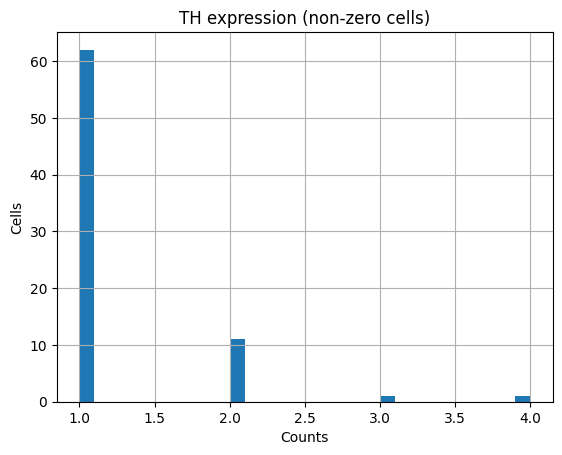

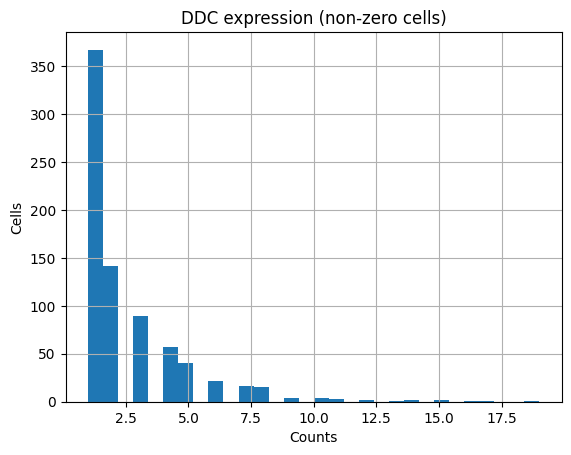

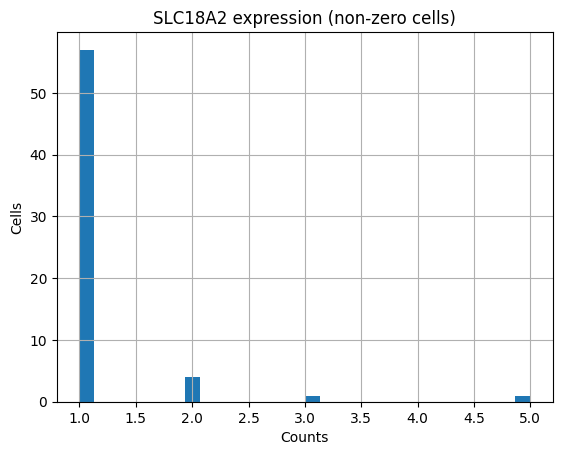

In [ ]:
import matplotlib.pyplot as plt

genes = ["TH","DDC","SLC18A2"]
for g in genes:
    if g in df.index:
        vals = df.loc[g]
        plt.figure()
        vals[vals>0].hist(bins=30)
        plt.title(f"{g} expression (non-zero cells)")
        plt.xlabel("Counts")
        plt.ylabel("Cells")
        plt.show()


In [ ]:
for g in genes:
    if g in df.index:
        vals = df.loc[g]
        pct = (vals>0).mean()*100
        print(f"{g}: {pct:.2f}% of cells express this gene")


TH: 1.67% of cells express this gene
DDC: 17.09% of cells express this gene
SLC18A2: 1.40% of cells express this gene


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.6/183.6 kB 12.7 MB/s eta 0:00:00
Marker mapping (None = not found): {'TH': 'TH', 'SLC6A3': None, 'DDC': 'DDC', 'SLC18A2': 'SLC18A2'}


,marker,gene,cluster,pct_express,mean_expr,n_cells
0,TH,TH,0,0.000000,-0.11519083,667
1,TH,TH,1,0.000000,-0.115190834,600
2,TH,TH,2,0.000000,-0.11519083,589
3,TH,TH,3,11.440678,0.4564963,472
4,TH,TH,4,0.000000,-0.11519083,455
5,TH,TH,5,0.000000,-0.115190834,413
6,TH,TH,6,0.000000,-0.11519083,402
7,TH,TH,7,5.691057,0.4423303,369
8,TH,TH,8,0.000000,-0.11519083,300
9,TH,TH,9,0.000000,-0.11519084,201


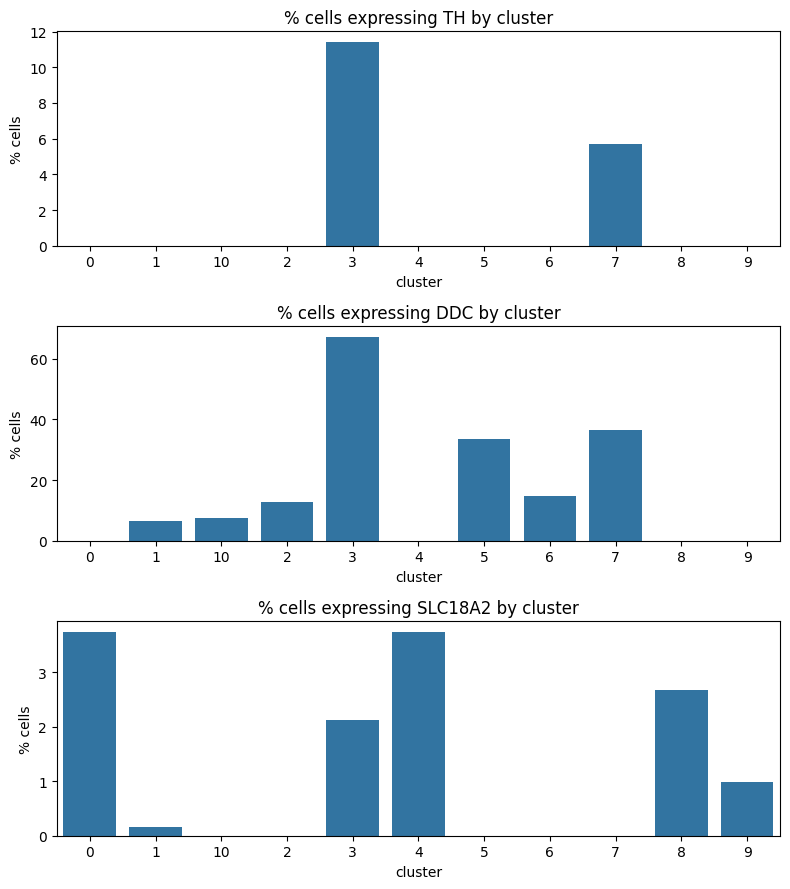

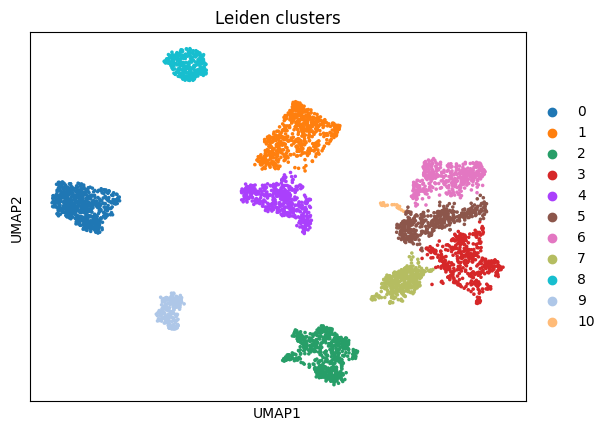

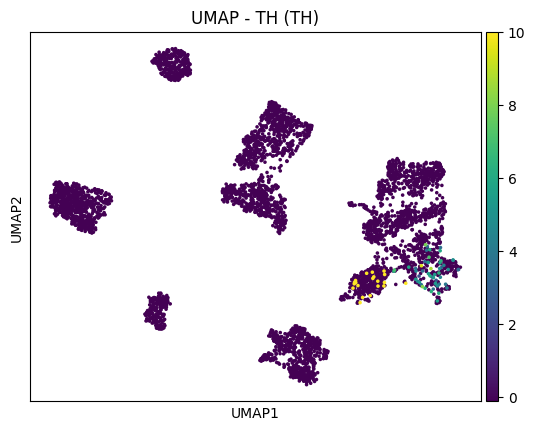

SLC6A3 not found, skipping UMAP


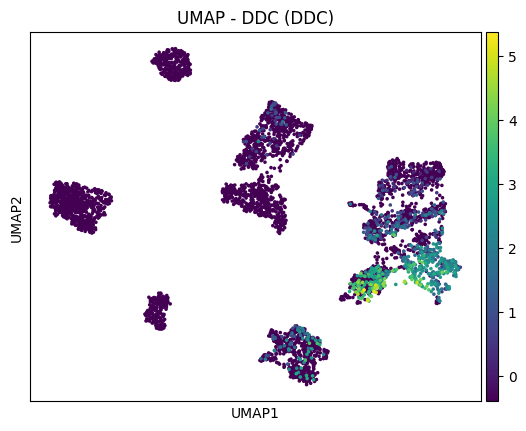

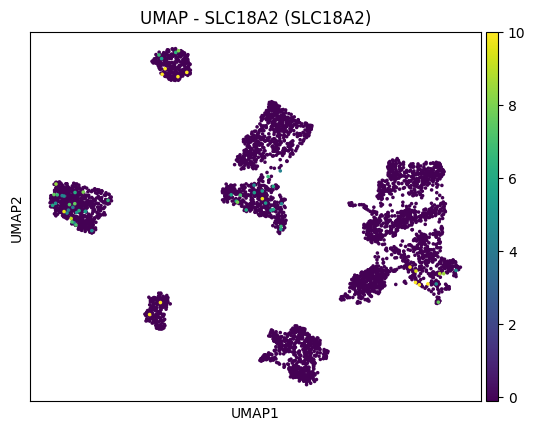


Candidate dopaminergic clusters (pct >= 1.0%): ['3', '7']

Mean expression in candidate clusters:


marker,DDC,SLC18A2,TH
cluster,,,
3,1.282459,0.072246,0.456496
7,0.966601,-0.108015,0.44233


In [ ]:
# Step 0: install required packages
!pip install --quiet scanpy igraph python-igraph leidenalg scikit-misc

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: ensure df exists
if 'df' not in globals():
    raise RuntimeError("DataFrame 'df' not found. Make sure you've loaded your gene x cell matrix into variable df.")

# Step 2: convert df to AnnData (cells x genes)
adata = sc.AnnData(df.T.copy())
adata.var_names_make_unique()

# Step 3: map markers to available gene names
markers = {"TH":"TH", "SLC6A3":"SLC6A3", "DDC":"DDC", "SLC18A2":"SLC18A2"}
var_up = [v.upper() for v in adata.var_names]
map_index_upper = dict(zip(var_up, adata.var_names))

found = {}
for k,g in markers.items():
    if g in adata.var_names:
        found[k] = g
    elif g.upper() in map_index_upper:
        found[k] = map_index_upper[g.upper()]
    else:
        found[k] = None
print("Marker mapping (None = not found):", found)

# Step 4: preprocess and cluster
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3')
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
sc.tl.leiden(adata, resolution=0.6)
sc.tl.umap(adata)

# Step 5: compute percent expressing per cluster
clusters = sorted(adata.obs['leiden'].astype(str).unique(), key=int)
summary_rows = []

for marker_name, varname in found.items():
    if varname is None:
        continue
    gene_idx = varname
    expr = adata[:, gene_idx].X.toarray().flatten() if hasattr(adata.X, "toarray") else adata[:, gene_idx].X.flatten()
    for cl in clusters:
        mask = adata.obs['leiden'] == cl
        vals = expr[mask.values]
        pct = (vals > 0).sum() / max(1, vals.size) * 100
        mean = vals.mean() if vals.size > 0 else 0
        summary_rows.append({"marker": marker_name, "gene": varname, "cluster": cl, "pct_express": pct, "mean_expr": mean, "n_cells": int(mask.sum())})

summary_df = pd.DataFrame(summary_rows)
display(summary_df.head(20))

# Step 6: bar plots
pivot = summary_df.pivot_table(index="cluster", columns="marker", values="pct_express").fillna(0)
plt.figure(figsize=(8,3*len([m for m in markers if found[m] is not None])))
for i, marker in enumerate([m for m in markers if found[m] is not None], start=1):
    plt.subplot(len([m for m in markers if found[m] is not None]), 1, i)
    sns.barplot(x=pivot.index, y=pivot[marker].values)
    plt.title(f"% cells expressing {marker} by cluster")
    plt.ylabel("% cells")
    plt.xlabel("cluster")
plt.tight_layout()
plt.show()

# Step 7: UMAP
sc.pl.umap(adata, color='leiden', title="Leiden clusters", show=True)
for marker_name, varname in found.items():
    if varname is None:
        print(f"{marker_name} not found, skipping UMAP")
        continue
    sc.pl.umap(adata, color=varname, title=f"UMAP - {marker_name} ({varname})", show=True)

# Step 8: candidate dopaminergic clusters
threshold_pct = 1.0
candidates = set()
for _, row in summary_df.iterrows():
    if row['marker'] in ('TH','SLC6A3') and row['pct_express'] >= threshold_pct:
        candidates.add(row['cluster'])
print("\nCandidate dopaminergic clusters (pct >= {:.1f}%):".format(threshold_pct), sorted(list(candidates)))

if candidates:
    cand = sorted(list(candidates))
    print("\nMean expression in candidate clusters:")
    display(summary_df[summary_df['cluster'].isin(cand)].pivot_table(index='cluster', columns='marker', values='mean_expr'))
